In [1]:
import scipy
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#PARAMETROS
muy = 0.1
muz = 0.0
PY=[0,0]
PZ=[0,0]
vizY = [4,8]
vizZ = [4,8]
vizX = 4
hy = [1.2/vizY[0],1.2/vizY[1]]
hz = [1.0/vizZ[0],1.0/vizZ[1]]
hx = 0.5
dz = 0.2
dy = 0.15

In [3]:
#Transições Aproximação de Campo Médio

def P0Xcm(P0,PX):
    return P0*(1-(1-hx*PX)**vizX)

def PXYcm(PX,PY):
    return PX*(1-(1-hy[1]*PY[1])**(vizY[1]-vizY[0])*(1-hy[1]*PY[1]-hy[0]*PY[0])**vizY[0])

def PXY1cm(PX,PY):
    return PX*(1-(1-hy[1]*PY[1])**(vizY[1]-vizY[0])*(1-hy[0]*PY[0]-hy[1]*PY[1])**vizY[0])/(2-(1-hy[0]*PY[0])**vizY[0]-(1-hy[1]*PY[1])**vizY[1]) * (muy/2*(1-(1-PY[1]*hy[1])**vizY[1])+(1-muy/2)*(1-(1-PY[0]*hy[0])**vizY[0]))

def PXY2cm(PX,PY):
    return PX*(1-(1-hy[1]*PY[1])**(vizY[1]-vizY[0])*(1-hy[0]*PY[0]-hy[1]*PY[1])**vizY[0])/(2-(1-hy[0]*PY[0])**vizY[0]-(1-hy[1]*PY[1])**vizY[1]) * (muy/2*(1-(1-PY[0]*hy[0])**vizY[0])+(1-muy/2)*(1-(1-PY[1]*hy[1])**vizY[1]))

def PY1Zcm(PY,PZ):
    return PY[0]*(1-(1-hz[1]*PZ[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PZ[1]-hz[0]*PZ[0])**vizZ[0])
    
def PY2Zcm(PY,PZ):
    return PY[1]*(1-(1-hz[1]*PZ[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PZ[1]-hz[0]*PZ[0])**vizZ[0])

def PY1Z1cm(PY,PZ):
    return PY[0]*(1-(1-hz[1]*PZ[1])**(vizZ[1]-vizZ[0])*(1-hz[0]*PZ[0]-hz[1]*PZ[1])**vizZ[0])/(2-(1-hz[0]*PZ[0])**vizZ[0]-(1-hz[1]*PZ[1])**vizZ[1]) * (muz/2*(1-(1-hz[1]*PZ[1])**vizZ[1])+(1-muz/2)*(1-(1-hz[0]*PZ[0])**vizZ[0]))
    
def PY2Z1cm(PY,PZ):
    return PY[1]*(1-(1-hz[1]*PZ[1])**(vizZ[1]-vizZ[0])*(1-hz[0]*PZ[0]-hz[1]*PZ[1])**vizZ[0])/(2-(1-hz[0]*PZ[0])**vizZ[0]-(1-hz[1]*PZ[1])**vizZ[1]) * (muz/2*(1-(1-hz[1]*PZ[1])**vizZ[1])+(1-muz/2)*(1-(1-hz[0]*PZ[0])**vizZ[0]))

def PY1Z2cm(PY,PZ):
    return PY[0]*(1-(1-hz[1]*PZ[1])**(vizZ[1]-vizZ[0])*(1-hz[0]*PZ[0]-hz[1]*PZ[1])**vizZ[0])/(2-(1-hz[0]*PZ[0])**vizZ[0]-(1-hz[1]*PZ[1])**vizZ[1]) * (muz/2*(1-(1-hz[0]*PZ[0])**vizZ[0])+(1-muz/2)*(1-(1-hz[1]*PZ[1])**vizZ[1]))

def PY2Z2cm(PY,PZ):
    return PY[1]*(1-(1-hz[1]*PZ[1])**(vizZ[1]-vizZ[0])*(1-hz[0]*PZ[0]-hz[1]*PZ[1])**vizZ[0])/(2-(1-hz[0]*PZ[0])**vizZ[0]-(1-hz[1]*PZ[1])**vizZ[1]) * (muz/2*(1-(1-hz[0]*PZ[0])**vizZ[0])+(1-muz/2)*(1-(1-hz[1]*PZ[1])**vizZ[1]))

In [4]:
#Transições Aproximação de Pares

def PX0par(P0,PX0):
    return P0*(1-(1-hx*PX0/P0)**vizX)

def pX0par2(P0,PX0):
    return (1-(1-hx*PX0/P0)**(vizX-1))

#############################################

def PXYpar(PX,PXY1,PXY2):
    return PX*(1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**vizY[0])

def PXYpar2(PX,PXY1,PXY2):
    return (1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**(vizY[0]-1))

#############################################

def PXY1par(PX,PXY1,PXY2):
    return PX*(1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**vizY[0])/((1-(1-PXY1/PX)**vizY[0])
            +(1-(1-PXY2/PX)**vizY[1]))*(muy/2*(1-(1-PXY2/PX)**vizY[1])+(1-muy/2)*(1-(1-PXY1/PX)**vizY[0]))

def PXY1par2(PX,PXY1,PXY2): 
    return (1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**(vizY[0]-1))/((1-(1-PXY1/PX)**(vizY[0]-1))
            +(1-(1-PXY2/PX)**(vizY[1]-1)))*(muy/2*(1-(1-PXY2/PX)**(vizY[1]-1))+(1-muy/2)*(1-(1-PXY1/PX)**(vizY[0]-1)))

#############################################

def PXY2par(PX,PXY1,PXY2): 
    return (PX*(1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**vizY[0])/((1-(1-PXY1/PX)**vizY[0])+(1-(1-PXY2/PX)**vizY[1]))
            *(muy/2*(1-(1-PXY1/PX)**vizY[0])+(1-muy/2)*(1-(1-PXY2/PX)**vizY[1])))

def PXY2par2(PX,PXY1,PXY2):
    return (1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**(vizY[0]-1))/((1-(1-PXY1/PX)**(vizY[0]-1))
            +(1-(1-PXY2/PX)**(vizY[1]-1)))*(muy/2*(1-(1-PXY1/PX)**(vizY[0]-1))+(1-muy/2)*(1-(1-PXY2/PX)**(vizY[1]-1)))

#############################################

def PY1Zpar(PY,PY1Z1,PY1Z2):
    return PY[0]*(1-(1-hz[1]*PY1Z2/PY[0])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY1Z2/PY[0]-hz[0]*PY1Z1/PY[0])**vizZ[0])

def PY1Zpar2(PY,PY1Z1,PY1Z2):
    return (1-(1-hz[1]*PY1Z2/PY[0])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY1Z2/PY[0]-hz[0]*PY1Z1/PY[0])**(vizZ[0]-1))

#############################################

def PY2Zpar(PY,PY2Z1,PY2Z2):
    return PY[1]*(1-(1-hz[1]*PY2Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY2Z2/PY[1]-hz[0]*PY2Z1/PY[1])**vizZ[0])

def PY2Zpar2(PY,PY2Z1,PY2Z2):
    return (1-(1-hz[1]*PY2Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY2Z2/PY[1]-hz[0]*PY2Z1/PY[1])**(vizZ[0]-1))

#############################################

def PY1Z1par(PY,PY1Z1,PY1Z2):
    return (PY[0]*(1-(1-hz[1]*PY1Z2/PY[0])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY1Z2/PY[0]-hz[0]*PY1Z1/PY[0])**vizZ[0])/((1-(1-PY1Z1/PY[0])**vizZ[0]+(1-(1-PY1Z2/PY[0])**vizZ[1])))
        * (muz/2*(1-(1-PY1Z2/PY[0])**vizZ[1])+(1-muz/2)*(1-(1-PY1Z1/PY[0])**vizZ[0])))

def PY1Z1par2(PY,PY1Z1,PY1Z2):
    return ((1-(1-hz[1]*PY1Z2/PY[0])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY1Z2/PY[0]-hz[0]*PY1Z1/PY[0])**(vizZ[0]-1))/((1-(1-PY1Z1/PY[0])**(vizZ[0]-1)+(1-(1-PY1Z2/PY[0])**(vizZ[1]-1))))
        * (muz/2*(1-(1-PY1Z2/PY[0])**(vizZ[1]-1))+(1-muz/2)*(1-(1-PY1Z1/PY[0])**(vizZ[0]-1))))

#############################################

def PY1Z2par(PY,PY1Z1,PY1Z2):
    return (PY[0]*(1-(1-hz[1]*PY1Z2/PY[0])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY1Z2/PY[0]-hz[0]*PY1Z1/PY[0])**vizZ[0])/((1-(1-PY1Z1/PY[0])**vizZ[0]+(1-(1-PY1Z2/PY[0])**vizZ[1])))
        * (muz/2*(1-(1-PY1Z1/PY[0])**vizZ[0])+(1-muz/2)*(1-(1-PY1Z2/PY[0])**vizZ[1])))

def PY1Z2par2(PY,PY1Z1,PY1Z2):
    return ((1-(1-hz[1]*PY1Z2/PY[0])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY1Z2/PY[0]-hz[0]*PY1Z1/PY[0])**(vizZ[0]-1))/((1-(1-PY1Z1/PY[0])**(vizZ[0]-1)+(1-(1-PY1Z2/PY[0])**(vizZ[1]-1))))
        * (muz/2*(1-(1-PY1Z1/PY[0])**(vizZ[0]-1))+(1-muz/2)*(1-(1-PY1Z2/PY[0])**(vizZ[1]-1))))

#############################################

def PY2Z1par(PY,PY2Z1,PY2Z2):
    return (PY[1]*(1-(1-hz[1]*PY2Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY2Z2/PY[1]-hz[0]*PY2Z1/PY[1])**vizZ[0])/((1-(1-PY2Z1/PY[1])**vizZ[0]+(1-(1-PY2Z2/PY[1])**vizZ[1])))
        * (muz/2*(1-(1-PY2Z2/PY[1])**vizZ[1])+(1-muz/2)*(1-(1-PY2Z1/PY[1])**vizZ[0])))

def PY2Z1par2(PY,PY2Z1,PY2Z2):
    return ((1-(1-hz[1]*PY2Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY2Z2/PY[1]-hz[0]*PY2Z1/PY[1])**(vizZ[0]-1))/((1-(1-PY2Z1/PY[1])**(vizZ[0]-1)+(1-(1-PY2Z2/PY[1])**(vizZ[1]-1))))
            * (muz/2*(1-(1-PY2Z2/PY[1])**(vizZ[1]-1))+(1-muz/2)*(1-(1-PY2Z1/PY[1])**(vizZ[0]-1))))

#############################################
def PY2Z2par(PY,PY2Z1,PY2Z2):
    return (PY[1]*(1-(1-hz[1]*PY2Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY2Z2/PY[1]-hz[0]*PY2Z1/PY[1])**vizZ[0])/((1-(1-PY2Z1/PY[1])**vizZ[0]+(1-(1-PY2Z2/PY[1])**vizZ[1])))
        * (muz/2*(1-(1-PY2Z1/PY[1])**vizZ[0])+(1-muz/2)*(1-(1-PY2Z2/PY[1])**vizZ[1])))

def PY2Z2par2(PY,PY2Z1,PY2Z2):
    return ((1-(1-hz[1]*PY2Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY2Z2/PY[1]-hz[0]*PY2Z1/PY[1])**(vizZ[0]-1))/((1-(1-PY2Z1/PY[1])**(vizZ[0]-1)+(1-(1-PY2Z2/PY[1])**(vizZ[1]-1))))
        * (muz/2*(1-(1-PY2Z1/PY[1])**(vizZ[0]-1))+(1-muz/2)*(1-(1-PY2Z2/PY[1])**(vizZ[1]-1))))

In [5]:
def Dinamica_cm(t):
    global PX, PY, PZ, P0
    PX = 0.3
    PY[0] = 0.15
    PY[1] = 0.15
    PZ[0] = 0.1
    PZ[1] = 0.1
    P0 = 1-PX-PY[0]-PY[1]-PZ[0]-PZ[1]
    for i in range(t):
        new_PX = PX + P0Xcm(P0, PX) - PXY1cm(PX, PY) - PXY2cm(PX,PY)
        new_PY1 = PY[0] + PXY1cm(PX, PY) - dy*PY[0]- (1-dy)*(PY1Z1cm(PY, PZ)+PY1Z2cm(PY,PZ)) 
        new_PY2 = PY[1] + PXY2cm(PX, PY) - dy*PY[1]- (1-dy)*(PY2Z2cm(PY, PZ)+PY2Z1cm(PY,PZ)) 
        new_PZ1 = PZ[0] +(1-dy)*(PY1Z1cm(PY, PZ)+PY2Z1cm(PY, PZ)) - dz*PZ[0] 
        new_PZ2 = PZ[1] +(1-dy)*(PY2Z2cm(PY, PZ)+PY1Z2cm(PY, PZ)) - dz*PZ[1]
        new_P0 = 1 - new_PX-new_PY2-new_PZ1-new_PY1-new_PZ2
        PX = new_PX
        PY[0] = new_PY1
        PY[1] = new_PY2
        PZ[0] = new_PZ1
        PZ[1] = new_PZ2
        P0 = new_P0
        vaziocm[i] = P0
        mediaxcm[i] = PX
        mediay1cm[i] = PY[0]
        mediay2cm[i] = PY[1]
        mediaz1cm[i] = PZ[0]
        mediaz2cm[i] = PZ[1]

In [6]:
def Dinamica_pares(t):
    dt = 1
    global P0,PX
    global PX0, PY10, PY20, PZ10, PZ20, P00, PXX
    global PXY1, PXY2, PXZ1, PXZ2, PY1Y1, PY1Y2, PY2Y2
    global PY2Z1, PY2Z2, PZ1Z1, PZ1Z2, PZ2Z2, PY1Z1, PY1Z2
    for i in range(t):
        new_PX = PX + dt*(PX0par(P0, PX0) - PXYpar(PX, PXY1, PXY2))
        new_PY2 = PY[1] + dt*(PXY2par(PX, PXY1, PXY2) - (1-dy)*PY2Zpar(PY, PY2Z1, PY2Z2) - dy*PY[1])
        new_PY1 = PY[0] + dt*(PXY1par(PX, PXY1, PXY2) - (1-dy)*PY1Zpar(PY, PY1Z1, PY1Z2) - dy*PY[0])
        new_PZ1 = PZ[0] + dt*((1-dy)*PY1Z1par(PY, PY1Z1, PY1Z2) + (1-dy)*PY2Z1par(PY, PY2Z1, PY2Z2) - dz*PZ[0])
        new_PZ2 = PZ[1] + dt*((1-dy)*PY1Z2par(PY, PY1Z1, PY1Z2) + (1-dy)*PY2Z2par(PY, PY2Z1, PY2Z2) - dz*PZ[1])
        new_P0 = 1 - new_PX - new_PY1 - new_PY2 - new_PZ1 - new_PZ2
        
        new_PX0 = PX0 + dt*(dy*(PXY1+PXY2) + dz*(PXZ1+PXZ2) + P00*pX0par2(P0, PX0) - (1-hx)*PX0*pX0par2(P0, PX0) - PX0*hx - PX0*PXYpar2(PX, PXY1, PXY2))
        
        new_PY20 = PY20 + dt*(dy*(PY1Y2+PY2Y2) + dz*(PY2Z1+PY2Z2) + PX0*PXY2par2(PX, PXY1, PXY2) - dy*PY20 - (1-dy)*PY20*PY2Zpar2(PY, PY2Z1, PY2Z2) - PY20*pX0par2(P0, PX0))

        new_PY10 = PY10 + dt*(dy*(PY1Y1+PY1Y2) + dz*(PY1Z1+PY1Z2) + PX0*PXY1par2(PX, PXY1, PXY2) - dy*PY10 - (1-dy)*PY10*PY1Zpar2(PY, PY1Z1, PY1Z2) - PY10*pX0par2(P0, PX0))
        
        new_PZ10 = PZ10 + dt*(dy*(PY1Z1+PY2Z1) + dz*(PZ1Z1+PZ1Z2) + (1-dy)*PY10*PY1Z1par2(PY, PY1Z1, PY1Z2) + (1-dy)*PY20*PY2Z1par2(PY, PY2Z1, PY2Z2) - PZ10*dz - PZ10*pX0par2(P0, PX0))
        
        new_PZ20 = PZ20 + dt*(dy*(PY1Z2+PY2Z2) + dz*(PZ1Z2+PZ2Z2) + (1-dy)*PY10*PY1Z2par2(PY, PY1Z1, PY1Z2) + (1-dy)*PY20*PY2Z2par2(PY, PY2Z1, PY2Z2) - PZ20*dz - PZ20*pX0par2(P0, PX0))

        ##################        
        new_PXY2 = PXY2 + dt*(PY20*pX0par2(P0, PX0) + PXX*PXY2par2(PX, PXY1, PXY2) - dy*PXY2 - hy[1]*PXY2 - (1-hy[1])*PXY2*PXY2par2(PX, PXY1, PXY2) - (1-dy)*PXY2*PY2Zpar2(PY, PY2Z1, PY2Z2))

        new_PXY1 = PXY1 + dt*(PY10*pX0par2(P0, PX0) + PXX*PXY1par2(PX, PXY1, PXY2) - dy*PXY1 - hy[0]*PXY1 - (1-hy[0])*PXY1*PXY1par2(PX, PXY1, PXY2) - (1-dy)*PXY1*PY1Zpar2(PY, PY1Z1, PY1Z2))
        
        new_PXZ1 = PXZ1 + dt*(PZ10*pX0par2(P0, PX0) + (1-dy)*PXY1*PY1Z1par2(PY, PY1Z1, PY1Z2) + (1-dy)*PXY2*PY2Z1par2(PY, PY2Z1, PY2Z2) - dz*PXZ1 - PXZ1*PXYpar2(PX, PXY1, PXY2))
        
        new_PXZ2 = PXZ2 + dt*(PZ20*pX0par2(P0, PX0) + (1-dy)*PXY1*PY1Z2par2(PY, PY1Z1, PY1Z2) + (1-dy)*PXY2*PY2Z2par2(PY, PY2Z1, PY2Z2) - dz*PXZ2 - PXZ2*PXYpar2(PX, PXY1, PXY2))
        
        ##################
        new_PY1Z1 = PY1Z1 + dt*(PXZ1*PXY1par2(PX, PXY1, PXY2) + (1-dy)*PY1Y1*PY1Z1par2(PY, PY1Z1, PY1Z2) + (1-dy)*PY1Y2*PY2Z1par2(PY, PY2Z1, PY2Z2) 
                                - (dy+dz)*PY1Z1 - hz[0]*PY1Z1 - (1-hz[0])*PY1Z1*PY1Zpar(PY, PY1Z1, PY1Z2))
        
        new_PY2Z1 = PY2Z1 + dt*(PXZ1*PXY2par2(PX, PXY1, PXY2) + (1-dy)*PY1Y2*PY1Z1par2(PY, PY1Z1, PY1Z2) + (1-dy)*PY2Y2*PY2Z1par2(PY, PY2Z1, PY2Z2)
                                - (dy+dz)*PY2Z1 - hz[0]*PY2Z1 - (1-hz[0])*PY2Z1*PY2Zpar(PY, PY2Z1, PY2Z2))

        new_PY2Z2 = PY2Z2 + dt*(PXZ2*PXY2par2(PX, PXY1, PXY2) + (1-dy)*PY1Y2*PY1Z2par2(PY, PY1Z1, PY1Z2) + (1-dy)*PY2Y2*PY2Z2par2(PY, PY2Z1, PY2Z2) - 
                                (dy+dz)*PY2Z2 - hz[1]*PY2Z2 - (1-hz[1])*PY2Z2*PY2Zpar(PY, PY2Z1, PY2Z2))
        
        new_PY1Z2 = PY1Z2 + dt*(PXZ2*PXY1par2(PX, PXY1, PXY2) + (1-dy)*PY1Y1*PY1Z2par2(PY, PY1Z1, PY1Z2) + (1-dy)*PY1Y2*PY2Z2par2(PY, PY2Z1, PY2Z2) 
        - (dy+dz)*PY1Z2 - hz[1]*PY1Z2 - (1-hz[1])*PY1Z2*PY1Zpar(PY, PY1Z1, PY1Z2))
                
        ##################
        new_PY1Y2 = PY1Y2 + dt*((1-hy[1])*PXY2*PXY1par2(PX, PXY1, PXY2) + (1-hy[0])*PXY1*PXY2par2(PX, PXY1, PXY2)
                     + PXY2*hy[1]*muy/2 + PXY1*hy[0]*muy/2 - 2*dy*PY1Y2 - (1-dy)*PY1Y2*(PY1Zpar2(PY, PY1Z1, PY1Z2) + PY2Zpar2(PY, PY2Z1, PY2Z2)))
        
        new_PZ1Z2 = PZ1Z2 + dt*((1-dy)*((1-hz[1])*(PY1Z2*PY1Z1par2(PY, PY1Z1, PY1Z2) + PY2Z2*PY2Z1par2(PY, PY2Z1, PY2Z2)) + 
                     (1-hz[0])*(PY2Z1*PY2Z2par2(PY, PY2Z1, PY2Z2) + PY1Z1*PY1Z2par2(PY, PY1Z1, PY1Z2)) + hz[1]*(PY1Z2+PY2Z2) + hz[0]*(PY1Z1+PY2Z1)) - 2*dz*PZ1Z2)
        
        ##################
        P00 = max(0,new_P0 - new_PX0 - new_PY10 - new_PY20 - new_PZ10 - new_PZ20)
        PXX = max(0,new_PX - new_PX0 - new_PXY2 -new_PXY1  - new_PXZ1 - new_PXZ2)
        PY2Y2 = max(0,new_PY2 - new_PXY2 - new_PY1Y2 - new_PY20- new_PY2Z1 - new_PY2Z2)
        PY1Y1 = max(0,new_PY1 - new_PY10 - new_PY1Y2 - new_PXY1- new_PY1Z1 - new_PY1Z2)
        PZ2Z2 = max(0,new_PZ2 - new_PXZ2 - new_PY1Z2 - new_PY2Z2 - new_PZ1Z2 - new_PZ20)
        PZ1Z1 = max(0,new_PZ1 - new_PZ10 - new_PXZ1 - new_PY1Z1 - new_PY2Z1 - new_PZ1Z2)
        ##################
        
        P0 = new_P0
        PX = new_PX
        PY[0] = new_PY1
        PY[1] = new_PY2
        PZ[0] = new_PZ2
        PZ[1] = new_PZ1
        PX0 = new_PX0
        PY10 = new_PY10
        PY20 = new_PY20
        PZ10 = new_PZ10
        PZ20 = new_PZ20
        PXY1 = new_PXY1
        PXY2 = new_PXY2
        PXZ1 = new_PXZ1
        PXZ2 = new_PXZ2
        PY1Z1 = new_PY1Z1
        PY1Z2 = new_PY1Z2
        PY2Z1 = new_PY2Z1
        PY2Z2 = new_PY2Z2
        PZ1Z2 = new_PZ1Z2
        PY1Y2 = new_PY1Y2
        vaziopares[i] = P0
        mediaxpares[i] = PX
        mediay1pares[i] = PY[0]
        mediay2pares[i] = PY[1]
        mediaz1pares[i] = PZ[0]
        mediaz2pares[i] = PZ[1]

In [7]:
# Condição inicial.

def condicao_inicial():
    global P0, PX, PY, PZ,hx
    global PX0, PY10, PY20, PZ10, PZ20, P00, PXX, PXY1, PXY2, PXZ1, PXZ2
    global PY1Y1, PY1Y2, PY1Z1, PY1Z2, PY2Y2, PY2Z1, PY2Z2, PZ1Z1, PZ1Z2, PZ2Z2
    PX = 0.2
    PY = [0.2, 0.2] # PY1, PY2
    PZ = [0.1, 0.1] # PZ1, PZ2
    P0 = 1.0 - (PX + PY[0] + PY[1] + PZ[0] + PZ[1])
    
    # Pares com Vazio (0)
    P00  = P0 * P0
    PX0  = PX * P0
    PY10 = PY[0] * P0
    PY20 = PY[1] * P0
    PZ10 = PZ[0] * P0
    PZ20 = PZ[1] * P0

    # Pares com Presa (X)
    PXX  = PX * PX
    PXY1 = PX * PY[0]
    PXY2 = PX * PY[1]
    PXZ1 = PX * PZ[0]
    PXZ2 = PX * PZ[1]

    # Pares entre Predadores e outros
    PY1Y1 = PY[0] * PY[0]
    PY1Y2 = PY[0] * PY[1]
    PY1Z1 = PY[0] * PZ[0]
    PY1Z2 = PY[0] * PZ[1]
    
    PY2Y2 = PY[1] * PY[1]
    PY2Z1 = PY[1] * PZ[0]
    PY2Z2 = PY[1] * PZ[1]
    PZ1Z1 = PZ[0] * PZ[0]
    PZ1Z2 = PZ[0] * PZ[1]
    PZ2Z2 = PZ[1] * PZ[1]

In [8]:
t = 4000
mediaxcm = np.zeros(t)
mediay1cm = np.zeros(t)
mediay2cm = np.zeros(t)
mediaz1cm = np.zeros(t)
mediaz2cm = np.zeros(t)
mediaxpares = np.zeros(t)
mediay1pares = np.zeros(t)
mediay2pares = np.zeros(t)
mediaz1pares = np.zeros(t)
mediaz2pares = np.zeros(t)
vaziocm = np.zeros(t)
vaziopares = np.zeros(t)
def zera_medidas():
    mediaxcm = np.zeros(t)
    mediay1cm = np.zeros(t)
    mediay2cm = np.zeros(t)
    mediaz1cm = np.zeros(t)
    mediaz2cm = np.zeros(t)
    mediaxpares = np.zeros(t)
    mediay1pares = np.zeros(t)
    mediay2pares = np.zeros(t)
    mediaz1pares = np.zeros(t)
    mediaz2pares = np.zeros(t)
    vaziocm = np.zeros(t)
    vaziopares = np.zeros(t)

In [14]:
y1cm = []
y2cm = []
xcm = []
z1cm = []
z2cm = []
y1par = []
y2par = []
z1par = []
z2par = []
xpar = []
difcm = []
difpar = []
muz = 0.0
muy = 0.1
vizY = [4,12]
vizZ = [0,20]
hz = [0, 1.0/vizZ[1]]
raio = [4,8,12,20,24,28,36,44,48,56,60,68,80,88,96,100, 108, 112, 120]
raios = [4,8,12,20,24,28,36,44,48,56,60,68,80]
for i in range(0,len(raios)):
    zera_medidas()
    vizY[1] = raio[i+1]
    vizY[0] = raio[i]
    hy = [1.2/vizY[0],1.2/vizY[1]]
    Dinamica_cm(t)
    y2cm.append(mediay2cm[-1])
    y1cm.append(mediay1cm[-1])
    z2cm.append(mediaz2cm[-1])
    z1cm.append(mediaz1cm[-1])
    xcm.append(mediaxcm[-1])
    condicao_inicial()
    Dinamica_pares(t)
    y2par.append(mediay2pares[-1])
    y1par.append(mediay1pares[-1])
    z2par.append(mediaz2pares[-1])
    z1par.append(mediaz1pares[-1])
    xpar.append(mediaxpares[-1])
    difpar.append(mediay2pares[-1]-mediay1pares[-1])
    difcm.append(mediay2cm[-1]-mediay1cm[-1])


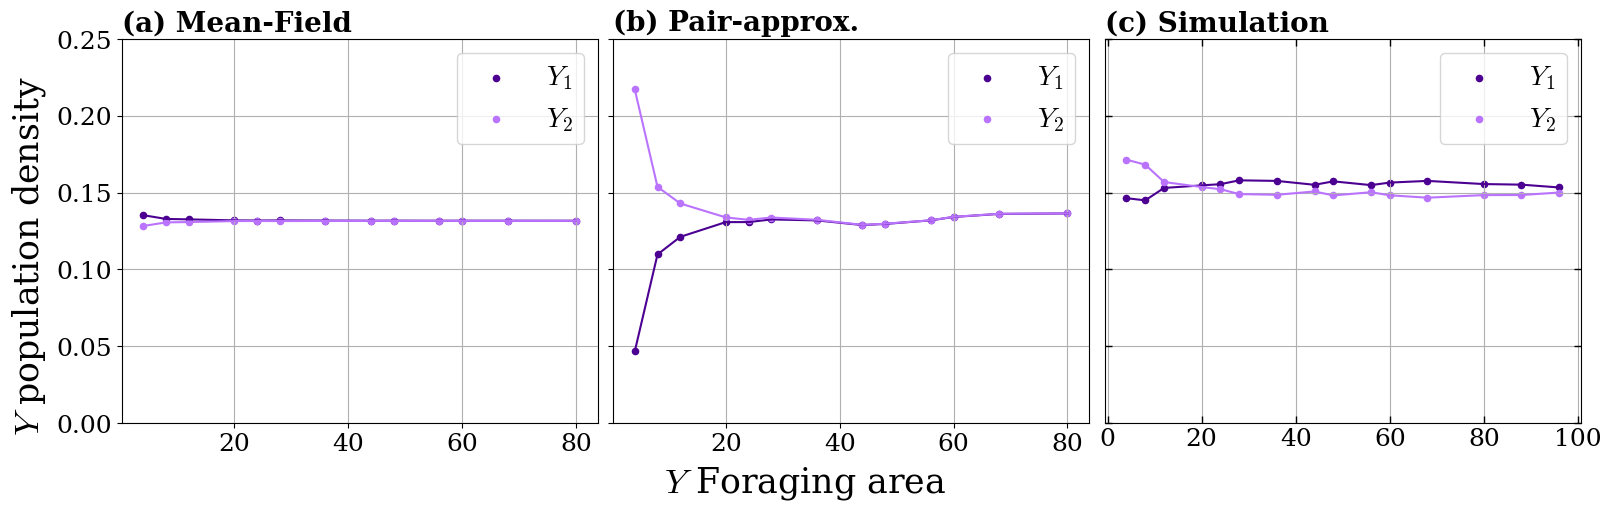

In [26]:
r, y1, y2, z4 = np.loadtxt("/home/lucas/Documents/doutorado/tres_especies_mutacao/popxarea/com_mut/popxareay.txt", unpack = True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
fig, ax = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True, sharey=True)
#plt.plot(raios, xcm,color = '#1AFF1A')
#plt.scatter(raios, xcm, s = 20, label = "X", color = '#1AFF1A', marker = 'v')
ax[0].plot(raios, y1cm,color = '#4B0092')
ax[0].scatter(raios, y1cm, s = 20,label = r"$Y_1$", color = '#4B0092', marker = 'o')
ax[0].plot(raios, y2cm,color = '#BA73FD')
ax[0].scatter(raios, y2cm, s = 20,label = r"$Y_2$", color = '#BA73FD', marker = 'o')
#plt.plot(raios, z2cm,color = '#FF0035')
#plt.scatter(raios, z2cm, s = 20,label = "Z", color = '#FF0035', marker = '*')
ax[0].set_ylim(0,0.25)
ax[0].legend(fontsize = 20)
ax[0].set_title('(a) Mean-Field', loc='left', fontweight='bold',fontsize = 20)
ax[0].tick_params(axis='both', labelsize=18)

plt.tick_params(which='both', direction='in', top=True, right=True, width=1.0, length=5)

#plt.plot(raios, xpar,color = '#1AFF1A')
#plt.scatter(raios, xpar, s = 20, label = "X", color = '#1AFF1A', marker = 'v')
ax[1].plot(raios, y1par,color = '#4B0092')
ax[1].scatter(raios, y1par, s = 20,label = r"$Y_1$", color = '#4B0092', marker = 'o')
ax[1].plot(raios, y2par,color = '#BA73FD')
ax[1].scatter(raios, y2par, s = 20,label = r"$Y_2$", color = '#BA73FD', marker = 'o')
ax[1].set_ylim(0,0.25)
ax[1].legend(fontsize = 20)
ax[1].set_title('(b) Pair-approx.', loc='left', fontweight='bold',fontsize = 20)
ax[1].tick_params(axis='both', labelsize=18)

ax[2].plot(r, y1,color = '#4B0092')
ax[2].scatter(r, y1, s = 20,label = r"$Y_1$", color = '#4B0092', marker = 'o')
ax[2].plot(r, y2,color = '#BA73FD')
ax[2].scatter(r, y2, s = 20,label = r"$Y_2$", color = '#BA73FD', marker = 'o')
ax[2].set_ylim(0,0.25)
ax[2].set_title('(c) Simulation', loc='left', fontweight='bold',fontsize = 20)
ax[2].legend(fontsize = 20)
ax[2].tick_params(axis='both', labelsize=18)
ax[0].grid()
ax[1].grid()
ax[2].grid()

plt.tick_params(which='both', direction='in', top=True, right=True, width=1.0, length=5)
fig.supxlabel(r"$Y$ Foraging area ", fontsize=25)
fig.supylabel(r"$Y$ population density", fontsize=25)
plt.savefig("y1y2par.pdf",bbox_inches = "tight")
plt.show()

In [9]:
y1cm = []
y2cm = []
xcm = []
z1cm = []
z2cm = []
y1par = []
y2par = []
z1par = []
z2par = []
xpar = []
difcm = []
difpar = []
muz = 0.1
muy = 0.0
vizY = [4,4]
hy = [1.2/vizY[0],1.2/vizY[1]]
vizZ = [4,8]
hz = [1.0/vizZ[0], 1.0/vizZ[1]]
raio = [4,8,12,20,24,28,36,44,48,56,60,68,80,88,96,100, 108, 112, 120]
raios = [4,8,12,20,24,28,36,44,48,56,60,68]
for i in range(0,len(raios)):
    zera_medidas()
    vizZ[1] = raio[i+1]
    vizZ[0] = raio[i]
    hz = [1.0/vizZ[0],1.0/vizZ[1]]
    Dinamica_cm(t)
    y1cm.append(2*mediay1cm[-1])
    z2cm.append(mediaz2cm[-1])
    z1cm.append(mediaz1cm[-1])
    xcm.append(mediaxcm[-1])
    condicao_inicial()
    Dinamica_pares(t)
    y1par.append(2*mediay1pares[-1])
    z2par.append(mediaz2pares[-1])
    z1par.append(mediaz1pares[-1])
    xpar.append(mediaxpares[-1])
    difpar.append(mediaz2pares[-1]-mediaz1pares[-1])
    difcm.append(mediaz2cm[-1]-mediaz1cm[-1])


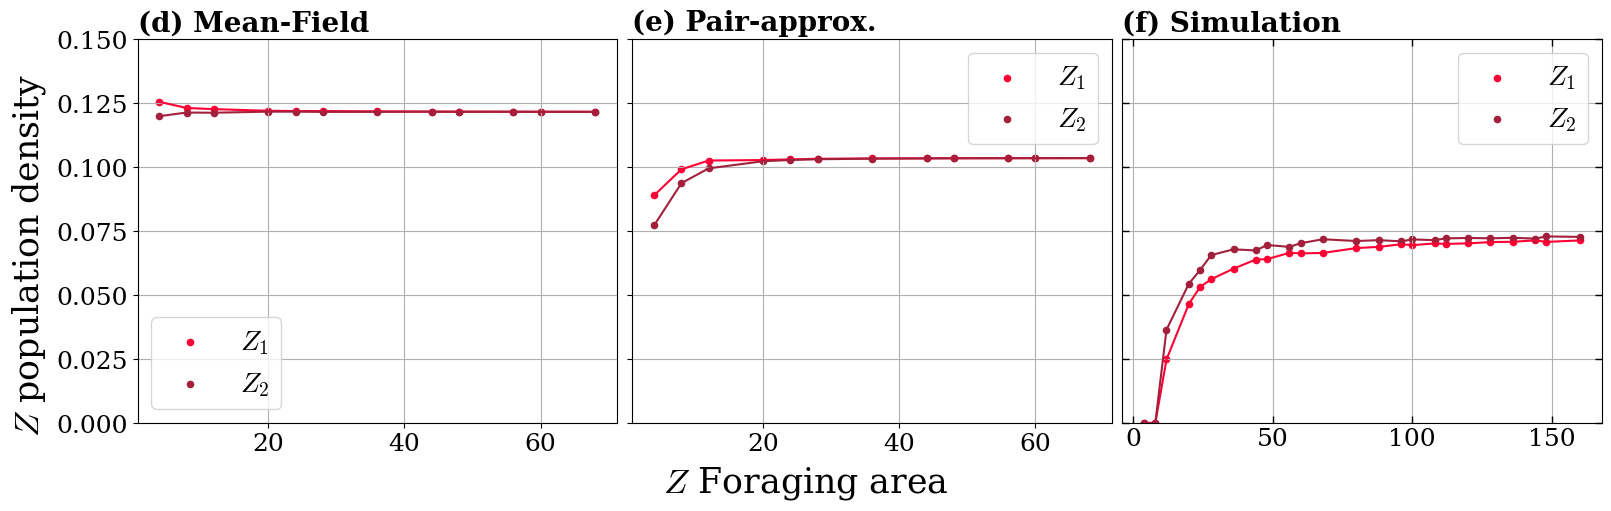

In [10]:
r, z1, z2, z4 = np.loadtxt("/home/lucas/Documents/doutorado/tres_especies_mutacao/popxarea/com_mut/popxareaz.txt", unpack = True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
fig, ax = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True, sharey=True)
#plt.plot(raios, xcm,color = '#1AFF1A')
#plt.scatter(raios, xcm, s = 20, label = "X", color = '#1AFF1A', marker = 'v')
ax[0].plot(raios, z1cm,color = '#FF0035')
ax[0].scatter(raios, z1cm, s = 20,label = r"$Z_1$", color = '#FF0035', marker = 'o')
ax[0].plot(raios, z2cm,color = '#A2203B')
ax[0].scatter(raios, z2cm, s = 20,label = r"$Z_2$", color = '#A2203B', marker = 'o')
#plt.plot(raios, z2cm,color = '#FF0035')
#plt.scatter(raios, z2cm, s = 20,label = "Z", color = '#FF0035', marker = '*')
ax[0].set_ylim(0,0.15)
ax[0].legend(fontsize = 20)
ax[0].set_title('(d) Mean-Field', loc='left', fontweight='bold',fontsize = 20)
ax[0].tick_params(axis='both', labelsize=18)

plt.tick_params(which='both', direction='in', top=True, right=True, width=1.0, length=5)

#plt.plot(raios, xpar,color = '#1AFF1A')
#plt.scatter(raios, xpar, s = 20, label = "X", color = '#1AFF1A', marker = 'v')
ax[1].plot(raios, z1par,color = '#FF0035')
ax[1].scatter(raios, z1par, s = 20,label = r"$Z_1$", color = '#FF0035', marker = 'o')
ax[1].plot(raios, z2par,color = '#A2203B')
ax[1].scatter(raios, z2par, s = 20,label = r"$Z_2$", color = '#A2203B', marker = 'o')
ax[1].set_title('(e) Pair-approx.', loc='left', fontweight='bold',fontsize = 20)
ax[1].tick_params(axis='both', labelsize=18)
ax[1].legend(fontsize = 20)
ax[1].set_ylim(0,0.15)

ax[2].plot(r, z1,color = '#FF0035')
ax[2].scatter(r, z1, s = 20,label = r"$Z_1$", color = '#FF0035', marker = 'o')
ax[2].plot(r, z2,color = '#A2203B')
ax[2].scatter(r, z2, s = 20,label = r"$Z_2$", color = '#A2203B', marker = 'o')
ax[2].set_title('(f) Simulation', loc='left', fontweight='bold',fontsize = 20)
ax[2].tick_params(axis='both', labelsize=18)
ax[2].set_ylim(0,0.15)
ax[2].legend(fontsize = 20)

plt.tick_params(which='both', direction='in', top=True, right=True, width=1.0, length=5)
fig.supxlabel(r"$Z$ Foraging area ", fontsize=25)
fig.supylabel(r"$Z$ population density", fontsize=25)
ax[0].grid()
ax[1].grid()
ax[2].grid()

plt.savefig("z1z2par.pdf", bbox_inches = "tight")
plt.show()